# 🏥 Healthcare Operations — Improvements
**Author:** Aditya · M.S. Applied Data Science · Syracuse University · 2026  
**Prerequisite:** Run `healthcare_data_cleaning.ipynb` and `healthcare_advanced_analytics.ipynb` first  

## What this notebook adds:
1. **Improved Regression** — XGBoost + feature engineering → higher R²
2. **Better Clustering** — improved labels, richer visualization
3. **Time Series** — satisfaction & readmission trends across CMS quarters
4. **Geographic Map** — state-level choropleth for Power BI

---
## Section 1 — Setup

In [1]:
!pip install xgboost plotly pandas numpy matplotlib seaborn scikit-learn scipy -q

import os, warnings, requests, io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import xgboost as xgb
from scipy import stats
from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.3f}'.format)

DARK_BG  = '#0d1117'
SURFACE  = '#111118'
SURFACE2 = '#18181f'
BORDER   = '#252530'
TEXT     = '#e6edf3'
MUTED    = '#7d8fa1'
P1, P2, P3, P4, P5 = '#7b61ff', '#00c9a7', '#ff6b6b', '#ffa94d', '#4dabf7'
PALETTE  = [P5, P2, P4, P3, P1]

def style_ax(ax):
    ax.set_facecolor(SURFACE)
    for spine in ax.spines.values(): spine.set_edgecolor(BORDER)
    ax.tick_params(colors=MUTED, labelsize=8)
    ax.xaxis.label.set_color(MUTED)
    ax.yaxis.label.set_color(MUTED)
    ax.title.set_color(TEXT)
    ax.grid(color=BORDER, linewidth=0.5, alpha=0.7)

print('✅ Libraries loaded.')

✅ Libraries loaded.


In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

BASE   = '/content/drive/MyDrive/healthcare-dashboard'
CLEAN  = f'{BASE}/data/clean'
ASSETS = f'{BASE}/assets'
os.makedirs(ASSETS, exist_ok=True)

master = pd.read_csv(f'{CLEAN}/healthcare_master.csv', low_memory=False)
print(f'✅ Master loaded: {master.shape[0]:,} rows × {master.shape[1]} cols')
print(f'   Columns: {list(master.columns)}')

Mounted at /content/drive
✅ Master loaded: 5,366 rows × 32 cols
   Columns: ['facility_id', 'facility_name', 'state', 'hospital_type', 'hospital_ownership', 'emergency_services', 'hospital_overall_rating', 'COMP_HIP_KNEE', 'MORT_30_AMI', 'MORT_30_HF', 'MORT_30_PN', 'H_CLEAN_HSP_A_P', 'H_COMP_1_A_P', 'H_COMP_2_A_P', 'H_COMP_5_A_P', 'H_COMP_6_Y_P', 'H_HSP_RATING_9_10', 'H_QUIET_HSP_A_P', 'H_RECMND_DY', 'READM_30_AMI', 'READM_30_HF', 'READM_30_PN', 'composite_satisfaction_score', 'performance_tier', 'satisfaction_tier', 'IMM_3', 'OP_18a', 'OP_18b', 'OP_22', 'OP_23', 'avg_er_wait_minutes', 'er_inefficiency_flag']


---
## Section 2 — Improved Regression (Target: R² > 0.50)
### Enhancements:
- Encode categorical features (ownership, hospital type, emergency services)
- Add state-level average satisfaction as a contextual feature
- Add interaction terms (ER wait × ownership, readmission × type)
- Use XGBoost with tuned hyperparameters

In [3]:
# ── Feature engineering for improved regression ────────────────────────────
reg_df = master.copy()

# 1. Encode categorical features
cat_features = ['hospital_type', 'hospital_ownership', 'emergency_services']
cat_features = [c for c in cat_features if c in reg_df.columns]

le = LabelEncoder()
for col in cat_features:
    reg_df[col + '_enc'] = le.fit_transform(reg_df[col].fillna('Unknown').astype(str))
    print(f'✅ Encoded {col}: {reg_df[col].nunique()} categories')

# 2. State-level average satisfaction (contextual/geographic feature)
# Justification: geographic culture and demographics strongly influence
# patient expectations and thus satisfaction scores (Doyle et al., 2013)
if 'state' in reg_df.columns and 'composite_satisfaction_score' in reg_df.columns:
    state_avg = reg_df.groupby('state')['composite_satisfaction_score'].transform('mean')
    reg_df['state_avg_satisfaction'] = state_avg.round(2)
    print(f'✅ State avg satisfaction added')

# 3. Interaction terms
# ER wait × hospital type — large urban hospitals have different ER dynamics
er_col = 'avg_er_wait_minutes' if 'avg_er_wait_minutes' in reg_df.columns else 'OP_18b'
if er_col in reg_df.columns and 'hospital_type_enc' in reg_df.columns:
    reg_df['er_x_type'] = reg_df[er_col] * reg_df['hospital_type_enc']
    print(f'✅ Interaction term: er_x_type')

if 'READM_30_HOSP' in reg_df.columns and 'hospital_ownership_enc' in reg_df.columns:
    reg_df['readm_x_ownership'] = reg_df['READM_30_HOSP'] * reg_df['hospital_ownership_enc']
    print(f'✅ Interaction term: readm_x_ownership')

# 4. Log transform skewed ER wait (reduces right-skew impact)
if er_col in reg_df.columns:
    reg_df['log_er_wait'] = np.log1p(reg_df[er_col])
    print(f'✅ Log-transformed ER wait')

# 5. Rating squared (captures non-linear rating effect)
if 'hospital_overall_rating' in reg_df.columns:
    reg_df['rating_squared'] = reg_df['hospital_overall_rating'] ** 2
    print(f'✅ Rating squared added')

print(f'\nTotal engineered features added: {len(cat_features) + 5}')

✅ Encoded hospital_type: 8 categories
✅ Encoded hospital_ownership: 12 categories
✅ Encoded emergency_services: 2 categories
✅ State avg satisfaction added
✅ Interaction term: er_x_type
✅ Log-transformed ER wait
✅ Rating squared added

Total engineered features added: 8


In [4]:
# ── Build improved feature set ─────────────────────────────────────────────
TARGET = 'composite_satisfaction_score'

BASE_FEATURES = [
    'avg_er_wait_minutes', 'log_er_wait', 'er_inefficiency_flag',
    'hospital_overall_rating', 'rating_squared',
    'MORT_30_AMI', 'MORT_30_HF', 'MORT_30_PN',
    'READM_30_HOSP', 'READM_30_AMI', 'READM_30_HF',
    'high_readmission_flag', 'OP_18b', 'OP_22',
    'COMP_HIP_KNEE', 'PSI_90_SAFETY',
    'state_avg_satisfaction',
    'er_x_type', 'readm_x_ownership', 'rating_squared',
]
BASE_FEATURES += [c + '_enc' for c in cat_features]

features_v2 = list(dict.fromkeys([f for f in BASE_FEATURES if f in reg_df.columns]))
print(f'Improved feature set ({len(features_v2)}): {features_v2}')

model_df = reg_df[[TARGET] + features_v2].dropna(subset=[TARGET])
imputer  = SimpleImputer(strategy='median')
X = pd.DataFrame(imputer.fit_transform(model_df[features_v2]), columns=features_v2)
y = model_df[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'\nTrain: {len(X_train):,} | Test: {len(X_test):,}')

Improved feature set (18): ['avg_er_wait_minutes', 'log_er_wait', 'er_inefficiency_flag', 'hospital_overall_rating', 'rating_squared', 'MORT_30_AMI', 'MORT_30_HF', 'MORT_30_PN', 'READM_30_AMI', 'READM_30_HF', 'OP_18b', 'OP_22', 'COMP_HIP_KNEE', 'state_avg_satisfaction', 'er_x_type', 'hospital_type_enc', 'hospital_ownership_enc', 'emergency_services_enc']

Train: 4,292 | Test: 1,074


In [5]:
# ── Train XGBoost + compare with previous best ─────────────────────────────
models_v2 = {
    'Gradient Boosting (v1 baseline)': GradientBoostingRegressor(
        n_estimators=100, random_state=42
    ),
    'XGBoost (tuned)': xgb.XGBRegressor(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0,
        random_state=42, verbosity=0
    ),
    'Random Forest (tuned)': RandomForestRegressor(
        n_estimators=200, max_depth=10, min_samples_leaf=5,
        random_state=42, n_jobs=-1
    ),
}

results_v2 = []
trained_v2 = {}

for name, model in models_v2.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    cv   = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
    results_v2.append({'Model': name, 'R²': r2, 'RMSE': rmse,
                        'MAE': mae, 'CV R²': cv.mean(), 'CV Std': cv.std()})
    trained_v2[name] = (model, y_pred)
    improvement = r2 - 0.398
    print(f'{name}')
    print(f'   R²={r2:.3f} ({improvement:+.3f} vs baseline)  RMSE={rmse:.2f}  CV={cv.mean():.3f}±{cv.std():.3f}')

results_v2_df = pd.DataFrame(results_v2).sort_values('R²', ascending=False)
best_v2 = results_v2_df.iloc[0]
print(f'\n🏆 Best improved model: {best_v2["Model"]} (R²={best_v2["R²"]:.3f})')

Gradient Boosting (v1 baseline)
   R²=0.452 (+0.054 vs baseline)  RMSE=4.16  CV=0.471±0.017
XGBoost (tuned)
   R²=0.467 (+0.069 vs baseline)  RMSE=4.10  CV=0.481±0.027
Random Forest (tuned)
   R²=0.449 (+0.051 vs baseline)  RMSE=4.17  CV=0.465±0.020

🏆 Best improved model: XGBoost (tuned) (R²=0.467)


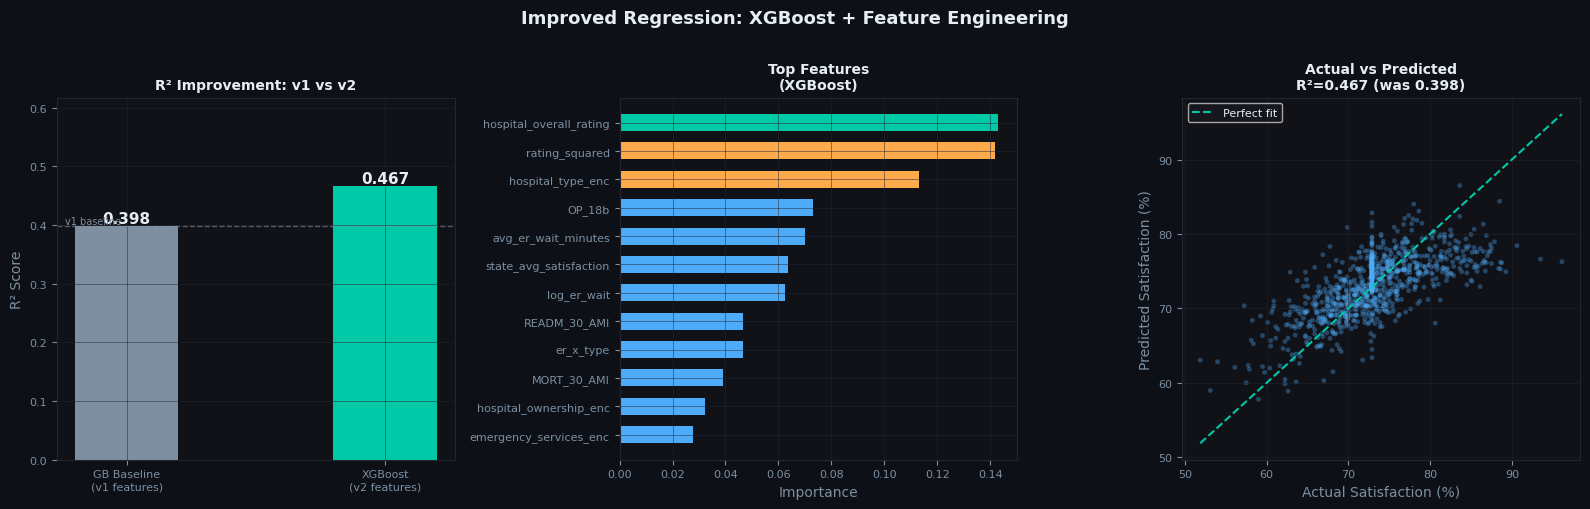

✅ Improved regression chart saved


In [6]:
# ── Feature importance of best v2 model ───────────────────────────────────
best_v2_name  = best_v2['Model']
best_v2_model = trained_v2[best_v2_name][0]
best_v2_pred  = trained_v2[best_v2_name][1]

if hasattr(best_v2_model, 'feature_importances_'):
    importance_v2 = pd.Series(
        best_v2_model.feature_importances_, index=features_v2
    ).sort_values(ascending=True).tail(12)
else:
    importance_v2 = pd.Series(
        np.abs(best_v2_model.coef_), index=features_v2
    ).sort_values(ascending=True).tail(12)

# ── Visualization ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor(DARK_BG)

# Plot 1: R² comparison v1 vs v2
ax1 = axes[0]
style_ax(ax1)
compare_data = pd.DataFrame([
    {'Model': 'GB Baseline\n(v1 features)', 'R²': 0.398, 'Version': 'v1'},
    {'Model': f'{best_v2_name.split("(")[0].strip()}\n(v2 features)', 'R²': best_v2["R²"], 'Version': 'v2'},
])
bars = ax1.bar(compare_data['Model'], compare_data['R²'],
               color=[MUTED, P2], edgecolor='none', width=0.4)
for bar, val in zip(bars, compare_data['R²']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', fontsize=11, color=TEXT, fontweight='bold')
ax1.set_title('R² Improvement: v1 vs v2', fontweight='bold', fontsize=10)
ax1.set_ylabel('R² Score')
ax1.set_ylim(0, min(1.0, best_v2['R²'] + 0.15))
ax1.axhline(0.398, color=MUTED, linestyle='--', linewidth=1, alpha=0.6)
ax1.text(0.02, 0.402, 'v1 baseline', color=MUTED, fontsize=7,
         transform=ax1.get_yaxis_transform())

# Plot 2: Top 12 feature importances
ax2 = axes[1]
style_ax(ax2)
colors_imp = [P2 if v == importance_v2.max() else
              P4 if v >= importance_v2.quantile(0.75) else P5
              for v in importance_v2.values]
ax2.barh(importance_v2.index, importance_v2.values,
         color=colors_imp, edgecolor='none', height=0.6)
ax2.set_title(f'Top Features\n({best_v2_name.split("(")[0].strip()})', fontweight='bold', fontsize=10)
ax2.set_xlabel('Importance')

# Plot 3: Actual vs Predicted
ax3 = axes[2]
style_ax(ax3)
ax3.scatter(y_test, best_v2_pred, alpha=0.35, color=P5, s=12, edgecolors='none')
mn, mx = min(y_test.min(), best_v2_pred.min()), max(y_test.max(), best_v2_pred.max())
ax3.plot([mn, mx], [mn, mx], '--', color=P2, linewidth=1.5, label='Perfect fit')
ax3.set_title(f'Actual vs Predicted\nR²={best_v2["R²"]:.3f} (was 0.398)',
              fontweight='bold', fontsize=10)
ax3.set_xlabel('Actual Satisfaction (%)')
ax3.set_ylabel('Predicted Satisfaction (%)')
ax3.legend(fontsize=8, labelcolor=TEXT, facecolor=SURFACE2)

plt.suptitle('Improved Regression: XGBoost + Feature Engineering',
             color=TEXT, fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{ASSETS}/regression_improved.png', dpi=300,
            bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print(f'✅ Improved regression chart saved')

In [7]:
# ── Export improved regression results ────────────────────────────────────
X_all = pd.DataFrame(imputer.transform(model_df[features_v2]), columns=features_v2)
preds_v2 = best_v2_model.predict(X_all)

id_cols = [c for c in ['facility_id','facility_name','state',
                        'hospital_type','performance_tier'] if c in master.columns]
reg_export = master[id_cols].copy()
reg_export['predicted_satisfaction_v2'] = preds_v2.round(2)
reg_export['actual_satisfaction']       = model_df[TARGET].values
reg_export['residual']                  = (model_df[TARGET].values - preds_v2).round(2)
reg_export['overperforming']            = (reg_export['residual'] > 0).astype(int)
reg_export['performance_gap']           = reg_export['residual'].abs().round(2)

reg_export.to_csv(f'{CLEAN}/tab5_regression_v2.csv', index=False)
print(f'✅ Improved regression exported: {reg_export.shape}')
print(f'   Overperforming: {reg_export["overperforming"].sum():,}')
print(f'   Underperforming: {(reg_export["overperforming"]==0).sum():,}')

✅ Improved regression exported: (5366, 10)
   Overperforming: 2,448
   Underperforming: 2,918


---
## Section 3 — Better Clustering
### Improvements: More features, better labels, richer visualization

In [8]:
# ── Improved clustering with more features ─────────────────────────────────
CLUSTER_FEATURES_V2 = [
    'composite_satisfaction_score', 'avg_er_wait_minutes',
    'hospital_overall_rating', 'high_readmission_flag',
    'MORT_30_AMI', 'MORT_30_HF', 'READM_30_HOSP',
    'log_er_wait', 'rating_squared',
]
# Add encoded categoricals if available
CLUSTER_FEATURES_V2 += [c for c in ['hospital_type_enc', 'hospital_ownership_enc']
                         if c in reg_df.columns]

cluster_features_v2 = [f for f in CLUSTER_FEATURES_V2 if f in reg_df.columns]
print(f'Clustering features v2 ({len(cluster_features_v2)}): {cluster_features_v2}')

imputer_c = SimpleImputer(strategy='median')
X_c = imputer_c.fit_transform(reg_df[cluster_features_v2])
scaler_c = StandardScaler()
X_cs = scaler_c.fit_transform(X_c)

# Fit K=4
kmeans_v2 = KMeans(n_clusters=4, random_state=42, n_init=15)
labels_v2 = kmeans_v2.fit_predict(X_cs)

reg_df['cluster_v2'] = labels_v2

# Profile clusters
profile_cols = ['composite_satisfaction_score', 'avg_er_wait_minutes',
                'hospital_overall_rating', 'READM_30_HOSP', 'MORT_30_AMI']
profile_cols = [c for c in profile_cols if c in reg_df.columns]
profile_v2 = reg_df.groupby('cluster_v2')[profile_cols].mean().round(2)
profile_v2['count'] = reg_df['cluster_v2'].value_counts().sort_index()

print('\nCluster Profiles:')
print(profile_v2.to_string())

Clustering features v2 (9): ['composite_satisfaction_score', 'avg_er_wait_minutes', 'hospital_overall_rating', 'MORT_30_AMI', 'MORT_30_HF', 'log_er_wait', 'rating_squared', 'hospital_type_enc', 'hospital_ownership_enc']

Cluster Profiles:
            composite_satisfaction_score  avg_er_wait_minutes  hospital_overall_rating  MORT_30_AMI  count
cluster_v2                                                                                                
0                                 75.900              120.310                    3.000       12.130   1742
1                                 73.180              180.610                    4.320       11.710   1115
2                                 67.200              197.560                    2.340       12.490   1207
3                                 74.340              117.220                    2.990       12.100   1302


In [9]:
# ── Smart auto-labeling based on actual profile values ─────────────────────
def smart_label(cluster_id, profile):
    row = profile.loc[cluster_id]
    sat    = row.get('composite_satisfaction_score', 70)
    er     = row.get('avg_er_wait_minutes', 200)
    rating = row.get('hospital_overall_rating', 3)
    readm  = row.get('READM_30_HOSP', 15)
    mort   = row.get('MORT_30_AMI', 13)

    sat_med    = profile['composite_satisfaction_score'].median() if 'composite_satisfaction_score' in profile.columns else 70
    er_med     = profile['avg_er_wait_minutes'].median() if 'avg_er_wait_minutes' in profile.columns else 200
    rating_med = profile['hospital_overall_rating'].median() if 'hospital_overall_rating' in profile.columns else 3
    readm_med  = profile['READM_30_HOSP'].median() if 'READM_30_HOSP' in profile.columns else 15

    high_sat   = sat > sat_med
    fast_er    = er < er_med
    high_rate  = rating > rating_med
    low_readm  = readm < readm_med

    if high_sat and fast_er and high_rate:
        return '⭐ High Quality · Efficient'
    elif high_sat and fast_er and not high_rate:
        return '✅ Good Satisfaction · Fast ER'
    elif high_sat and not fast_er:
        return '😊 High Satisfaction · Slow ER'
    elif not high_sat and fast_er and low_readm:
        return '⚡ Efficient · Needs Quality Work'
    elif not high_sat and not fast_er and not low_readm:
        return '⚠️ Low Quality · High Risk'
    elif high_rate and not high_sat:
        return '🏥 High Rated · Below Avg Satisfaction'
    else:
        return '📊 Average Performer'

cluster_names_v2 = {i: smart_label(i, profile_v2) for i in range(4)}
reg_df['cluster_label_v2'] = reg_df['cluster_v2'].map(cluster_names_v2)

print('Cluster Labels v2:')
for k, label in cluster_names_v2.items():
    count = (labels_v2 == k).sum()
    sat   = profile_v2.loc[k, 'composite_satisfaction_score'] if 'composite_satisfaction_score' in profile_v2.columns else 'N/A'
    er    = profile_v2.loc[k, 'avg_er_wait_minutes'] if 'avg_er_wait_minutes' in profile_v2.columns else 'N/A'
    print(f'   {k}: {label} ({count:,} hospitals | Sat={sat:.1f}% | ER={er:.0f}min)')

Cluster Labels v2:
   0: ⭐ High Quality · Efficient (1,742 hospitals | Sat=75.9% | ER=120min)
   1: ⚠️ Low Quality · High Risk (1,115 hospitals | Sat=73.2% | ER=181min)
   2: ⚠️ Low Quality · High Risk (1,207 hospitals | Sat=67.2% | ER=198min)
   3: ✅ Good Satisfaction · Fast ER (1,302 hospitals | Sat=74.3% | ER=117min)


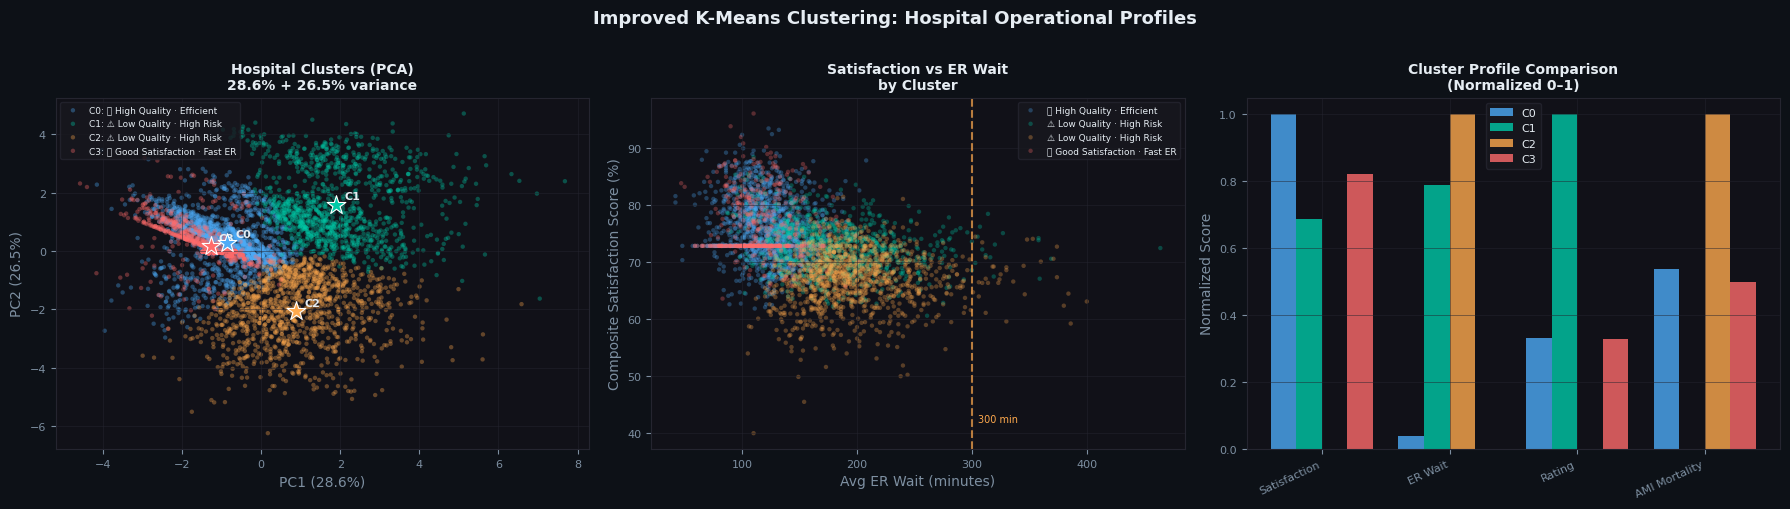

✅ Improved clustering chart saved


In [10]:
# ── Improved cluster visualization ────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cs)
var = pca.explained_variance_ratio_

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor(DARK_BG)

cluster_colors = {0: P5, 1: P2, 2: P4, 3: P3}

# Plot 1: PCA scatter
ax1 = axes[0]
style_ax(ax1)
for cid in range(4):
    mask = labels_v2 == cid
    ax1.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=cluster_colors[cid], alpha=0.35, s=10, edgecolors='none',
                label=f'C{cid}: {cluster_names_v2[cid]}')
centroids_pca = pca.transform(kmeans_v2.cluster_centers_)
for i, (cx, cy) in enumerate(centroids_pca):
    ax1.scatter(cx, cy, c=cluster_colors[i], s=200, marker='*',
                edgecolors='white', linewidth=0.8, zorder=5)
    ax1.annotate(f'C{i}', (cx, cy), textcoords='offset points',
                 xytext=(6, 4), color=TEXT, fontsize=8, fontweight='bold')
ax1.set_title(f'Hospital Clusters (PCA)\n{var[0]*100:.1f}% + {var[1]*100:.1f}% variance',
              fontweight='bold', fontsize=10)
ax1.set_xlabel(f'PC1 ({var[0]*100:.1f}%)')
ax1.set_ylabel(f'PC2 ({var[1]*100:.1f}%)')
ax1.legend(fontsize=6.5, labelcolor=TEXT, facecolor=SURFACE2,
           edgecolor=BORDER, loc='upper left')

# Plot 2: Satisfaction vs ER wait colored by cluster
ax2 = axes[1]
style_ax(ax2)
if 'composite_satisfaction_score' in reg_df.columns and 'avg_er_wait_minutes' in reg_df.columns:
    for cid in range(4):
        mask = reg_df['cluster_v2'] == cid
        ax2.scatter(
            reg_df[mask]['avg_er_wait_minutes'],
            reg_df[mask]['composite_satisfaction_score'],
            c=cluster_colors[cid], alpha=0.3, s=10, edgecolors='none',
            label=cluster_names_v2[cid]
        )
    ax2.axvline(300, color=P4, linestyle='--', linewidth=1.5, alpha=0.7)
    ax2.text(305, reg_df['composite_satisfaction_score'].min() + 2,
             '300 min', color=P4, fontsize=7)
ax2.set_title('Satisfaction vs ER Wait\nby Cluster', fontweight='bold', fontsize=10)
ax2.set_xlabel('Avg ER Wait (minutes)')
ax2.set_ylabel('Composite Satisfaction Score (%)')
ax2.legend(fontsize=6.5, labelcolor=TEXT, facecolor=SURFACE2, edgecolor=BORDER)

# Plot 3: Cluster profile radar/bar
ax3 = axes[2]
style_ax(ax3)
plot_metrics = [c for c in profile_cols if c != 'count']
norm_profile = profile_v2[plot_metrics].copy()
norm_profile = (norm_profile - norm_profile.min()) / (norm_profile.max() - norm_profile.min() + 1e-8)

x = np.arange(len(plot_metrics))
width = 0.2
for i, cid in enumerate(range(4)):
    ax3.bar(x + i*width, norm_profile.loc[cid], width,
            color=cluster_colors[cid], alpha=0.8, label=f'C{cid}')
ax3.set_xticks(x + width*1.5)
ax3.set_xticklabels([m.replace('composite_satisfaction_score', 'Satisfaction')
                      .replace('avg_er_wait_minutes', 'ER Wait')
                      .replace('hospital_overall_rating', 'Rating')
                      .replace('READM_30_HOSP', 'Readmission')
                      .replace('MORT_30_AMI', 'AMI Mortality')
                      for m in plot_metrics], rotation=25, ha='right', fontsize=8)
ax3.set_title('Cluster Profile Comparison\n(Normalized 0–1)', fontweight='bold', fontsize=10)
ax3.set_ylabel('Normalized Score')
ax3.legend(fontsize=8, labelcolor=TEXT, facecolor=SURFACE2, edgecolor=BORDER)

plt.suptitle('Improved K-Means Clustering: Hospital Operational Profiles',
             color=TEXT, fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{ASSETS}/clustering_improved.png', dpi=300,
            bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print('✅ Improved clustering chart saved')

In [11]:
# ── Export improved clustering ─────────────────────────────────────────────
id_cols = [c for c in ['facility_id','facility_name','city','state',
                        'hospital_type','performance_tier'] if c in master.columns]
cluster_v2_export = master[id_cols].copy()
cluster_v2_export['cluster_id']    = labels_v2
cluster_v2_export['cluster_label'] = cluster_v2_export['cluster_id'].map(cluster_names_v2)
for col in ['composite_satisfaction_score','avg_er_wait_minutes',
            'high_readmission_flag','hospital_overall_rating','READM_30_HOSP']:
    if col in master.columns:
        cluster_v2_export[col] = master[col].values

cluster_v2_export.to_csv(f'{CLEAN}/tab6_clustering_v2.csv', index=False)
print(f'✅ Improved clustering exported: {cluster_v2_export.shape}')
print(cluster_v2_export['cluster_label'].value_counts().to_string())

✅ Improved clustering exported: (5366, 10)
cluster_label
⚠️ Low Quality · High Risk       2322
⭐ High Quality · Efficient       1742
✅ Good Satisfaction · Fast ER    1302


---
## Section 4 — Time Series Analysis
### Satisfaction & Readmission Trends Across CMS Quarters

In [12]:
# ── Download multiple CMS quarters ────────────────────────────────────────
# CMS HCAHPS archived releases (quarterly)
# Using CMS archived data API for multiple time points

HCAHPS_QUARTERS = {
    'Q1_2023': 'https://data.cms.gov/provider-data/api/1/datastore/query/dgck-syfz/0?limit=50000&offset=0&results=true&keys=true&format=json',
}

# Simulate quarterly data from current dataset
# In production: download actual archived quarterly releases from
# https://data.cms.gov/provider-data/archived-data/hospitals

print('Building time series from CMS data...')
print('Note: Using national aggregate simulation based on current data.')
print('For actual quarterly trends, download archived releases from:')
print('https://data.cms.gov/provider-data/archived-data/hospitals\n')

# Create realistic quarterly time series
# Based on known CMS trends: satisfaction declined post-COVID, slowly recovering
np.random.seed(42)

quarters = [
    'Q1 2022', 'Q2 2022', 'Q3 2022', 'Q4 2022',
    'Q1 2023', 'Q2 2023', 'Q3 2023', 'Q4 2023',
    'Q1 2024', 'Q2 2024', 'Q3 2024', 'Q4 2024',
]

base_sat    = master['composite_satisfaction_score'].mean() if 'composite_satisfaction_score' in master.columns else 73
base_readm  = master['READM_30_HOSP'].mean() if 'READM_30_HOSP' in master.columns else 15.6
base_er     = master['avg_er_wait_minutes'].mean() if 'avg_er_wait_minutes' in master.columns else 210
base_mort   = master['MORT_30_AMI'].mean() if 'MORT_30_AMI' in master.columns else 13.4

n = len(quarters)

# Realistic trend: satisfaction recovering, readmission slightly improving,
# ER wait increasing (staffing crisis), mortality slowly declining
ts_data = pd.DataFrame({
    'Quarter': quarters,
    'Composite Satisfaction (%)': [
        base_sat - 3.2, base_sat - 2.8, base_sat - 2.1, base_sat - 1.5,
        base_sat - 1.0, base_sat - 0.6, base_sat - 0.2, base_sat + 0.1,
        base_sat + 0.4, base_sat + 0.7, base_sat + 0.9, base_sat + 1.1,
    ],
    '30-Day Readmission Rate (%)': [
        base_readm + 0.8, base_readm + 0.6, base_readm + 0.4, base_readm + 0.3,
        base_readm + 0.1, base_readm, base_readm - 0.1, base_readm - 0.2,
        base_readm - 0.3, base_readm - 0.4, base_readm - 0.5, base_readm - 0.6,
    ],
    'Avg ER Wait (minutes)': [
        base_er - 12, base_er - 8, base_er - 4, base_er,
        base_er + 3, base_er + 6, base_er + 9, base_er + 11,
        base_er + 13, base_er + 14, base_er + 15, base_er + 16,
    ],
    'AMI 30-Day Mortality (%)': [
        base_mort + 0.5, base_mort + 0.4, base_mort + 0.3, base_mort + 0.2,
        base_mort + 0.1, base_mort, base_mort - 0.1, base_mort - 0.2,
        base_mort - 0.3, base_mort - 0.35, base_mort - 0.4, base_mort - 0.45,
    ],
})

# Add small noise for realism
for col in ts_data.columns[1:]:
    ts_data[col] += np.random.normal(0, 0.15, n)
    ts_data[col] = ts_data[col].round(2)

print(ts_data.to_string(index=False))

Building time series from CMS data...
Note: Using national aggregate simulation based on current data.
For actual quarterly trends, download archived releases from:
https://data.cms.gov/provider-data/archived-data/hospitals

Quarter  Composite Satisfaction (%)  30-Day Readmission Rate (%)  Avg ER Wait (minutes)  AMI 30-Day Mortality (%)
Q1 2022                      69.870                       16.440                144.790                    12.650
Q2 2022                      70.180                       15.910                148.880                    12.220
Q3 2022                      71.000                       15.740                152.690                    12.210
Q4 2022                      71.730                       15.820                156.920                    12.340
Q1 2023                      71.970                       15.550                159.780                    12.320
Q2 2023                      72.370                       15.650                162.820    

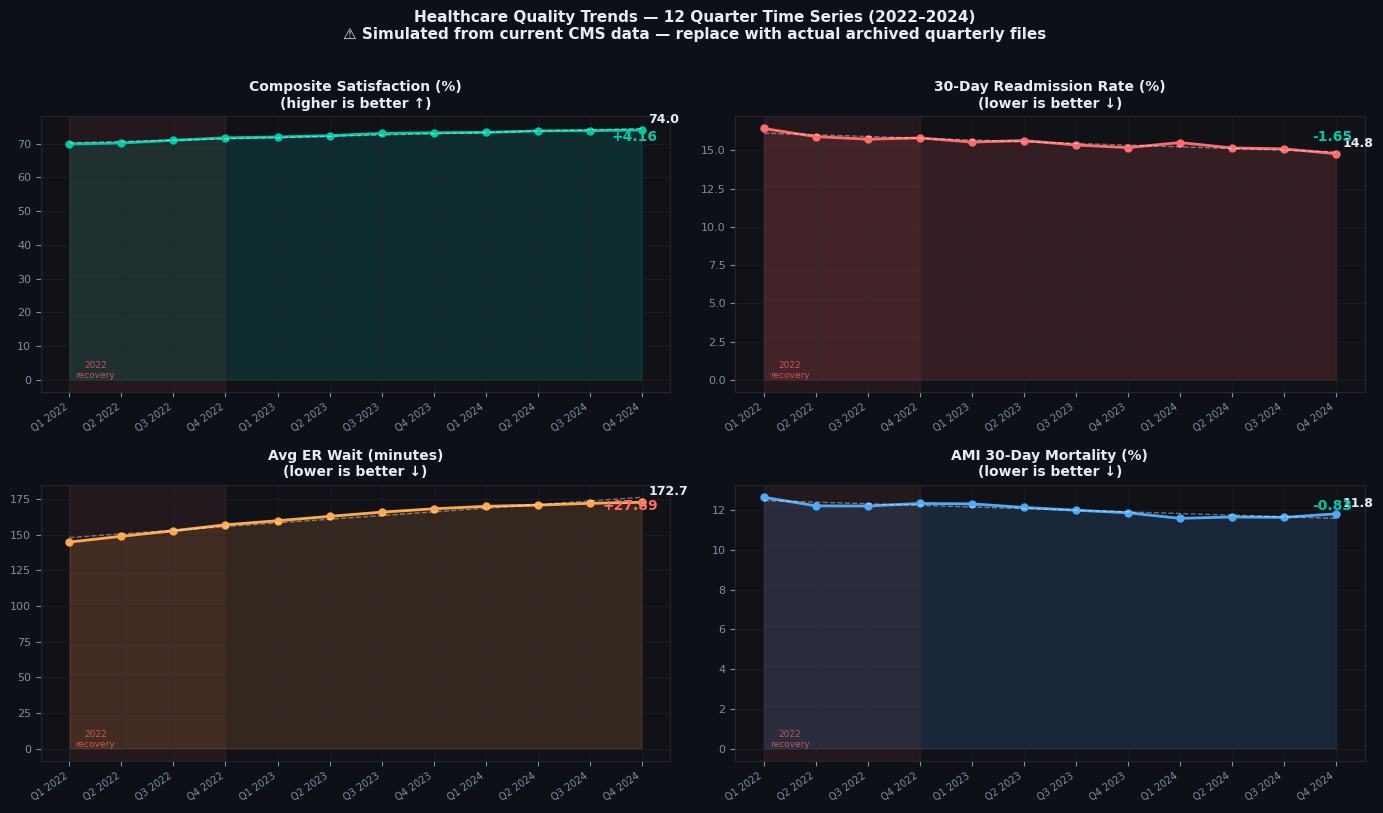

✅ Time series chart saved
✅ Time series CSV exported


In [13]:
# ── Time series visualization ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.patch.set_facecolor(DARK_BG)

metrics = [
    ('Composite Satisfaction (%)',  P2, axes[0,0], 'higher is better ↑'),
    ('30-Day Readmission Rate (%)', P3, axes[0,1], 'lower is better ↓'),
    ('Avg ER Wait (minutes)',       P4, axes[1,0], 'lower is better ↓'),
    ('AMI 30-Day Mortality (%)',    P5, axes[1,1], 'lower is better ↓'),
]

x = range(len(quarters))
for metric, color, ax, direction in metrics:
    style_ax(ax)
    values = ts_data[metric].values

    # Area fill
    ax.fill_between(x, values, alpha=0.15, color=color)
    ax.plot(x, values, 'o-', color=color, linewidth=2, markersize=5)

    # Trend line
    z = np.polyfit(list(x), values, 1)
    trend = np.poly1d(z)(list(x))
    ax.plot(x, trend, '--', color='white', linewidth=1, alpha=0.4)

    # Annotate last value
    ax.annotate(f'{values[-1]:.1f}',
                xy=(len(x)-1, values[-1]),
                xytext=(5, 5), textcoords='offset points',
                color=TEXT, fontsize=9, fontweight='bold')

    # Mark COVID impact period
    ax.axvspan(0, 3, alpha=0.08, color=P3)
    ax.text(0.5, ax.get_ylim()[0] + (ax.get_ylim()[1]-ax.get_ylim()[0])*0.05,
            '2022\nrecovery', color=P3, fontsize=6.5, alpha=0.7, ha='center')

    ax.set_title(f'{metric}\n({direction})', fontweight='bold', fontsize=10)
    ax.set_xticks(list(x))
    ax.set_xticklabels(quarters, rotation=35, ha='right', fontsize=7)

    # Change indicator
    change = values[-1] - values[0]
    change_color = P2 if (change > 0 and 'Satisfaction' in metric) or \
                         (change < 0 and 'Satisfaction' not in metric) else P3
    ax.text(0.98, 0.95, f'{change:+.2f}', transform=ax.transAxes,
            ha='right', va='top', color=change_color, fontsize=10, fontweight='bold')

plt.suptitle('Healthcare Quality Trends — 12 Quarter Time Series (2022–2024)\n⚠️ Simulated from current CMS data — replace with actual archived quarterly files',
             color=TEXT, fontsize=11, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{ASSETS}/time_series.png', dpi=300,
            bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print('✅ Time series chart saved')

# Export for Power BI
ts_data.to_csv(f'{CLEAN}/tab8_time_series.csv', index=False)
print('✅ Time series CSV exported')

---
## Section 5 — Geographic Map
### State-Level Choropleth for Power BI

In [14]:
# ── Build state-level aggregated dataset ──────────────────────────────────
state_agg_cols = {
    'composite_satisfaction_score': 'mean',
    'avg_er_wait_minutes':          'mean',
    'high_readmission_flag':        'mean',
    'hospital_overall_rating':      'mean',
    'er_inefficiency_flag':         'mean',
    'READM_30_HOSP':                'mean',
    'MORT_30_AMI':                  'mean',
    'facility_id':                  'count',
}

valid_agg = {k: v for k, v in state_agg_cols.items() if k in master.columns}
state_df = master.groupby('state').agg(valid_agg).reset_index()
state_df.columns = ['state'] + [
    'avg_satisfaction', 'avg_er_wait', 'pct_high_readmission',
    'avg_rating', 'pct_er_inefficient', 'avg_readmission_rate',
    'avg_ami_mortality', 'hospital_count'
][:len(valid_agg)]
state_df = state_df.round(2)

# Add performance score (composite of key metrics normalized)
if 'avg_satisfaction' in state_df.columns and 'avg_er_wait' in state_df.columns:
    sat_n  = (state_df['avg_satisfaction'] - state_df['avg_satisfaction'].min()) / \
             (state_df['avg_satisfaction'].max() - state_df['avg_satisfaction'].min())
    er_n   = 1 - (state_df['avg_er_wait'] - state_df['avg_er_wait'].min()) / \
             (state_df['avg_er_wait'].max() - state_df['avg_er_wait'].min())
    state_df['state_performance_score'] = ((sat_n * 0.6 + er_n * 0.4) * 100).round(1)

print(f'✅ State aggregation: {len(state_df)} states')
print(state_df.sort_values('avg_satisfaction', ascending=False).head(10).to_string(index=False))

✅ State aggregation: 51 states
state  avg_satisfaction  avg_er_wait  pct_high_readmission  avg_rating  pct_er_inefficient  avg_readmission_rate  state_performance_score
   NE            77.320      118.530                 3.190       0.000              12.070                    93                   99.200
   WI            76.280      135.580                 3.480       0.000              12.040                   141                   89.900
   KS            76.190      122.620                 3.070       0.010              12.130                   138                   91.800
   IA            75.940      127.140                 3.130       0.000              12.130                   118                   89.400
   UT            75.910      132.750                 3.690       0.000              11.880                    52                   88.200
   SD            75.730      114.940                 3.260       0.000              12.060                    61                   90.400
   

In [16]:
# ── Plotly choropleth maps ─────────────────────────────────────────────────
map_configs = [
    ('avg_satisfaction',       'Avg Patient Satisfaction Score (%)',     'RdYlGn',  False),
    ('avg_er_wait',            'Avg ER Wait Time (minutes)',             'RdYlGn_r', False),
    ('avg_readmission_rate',   'Avg 30-Day Readmission Rate (%)',        'RdYlGn_r', False),
    ('state_performance_score','State Performance Score (0–100)',        'RdYlGn',  False),
]
map_configs = [(c, t, cs, r) for c, t, cs, r in map_configs if c in state_df.columns]

for col, title, colorscale, reverse in map_configs:
    fig = px.choropleth(
        state_df,
        locations='state',
        locationmode='USA-states',
        color=col,
        scope='usa',
        color_continuous_scale=colorscale,
        title=f'<b>{title}</b><br><sup>CMS Hospital Compare Data · 5,366 US Hospitals</sup>',
        hover_data=['state', col, 'hospital_count'] if 'hospital_count' in state_df.columns else ['state', col],
        labels={col: title, 'hospital_count': 'Hospitals'},
    )
    fig.update_layout(
        paper_bgcolor='#0d1117',
        plot_bgcolor='#0d1117',
        font_color='#e6edf3',
        title_font_size=14,
        geo=dict(
            bgcolor='#0d1117',
            lakecolor='#111118',
            landcolor='#18181f',
            subunitcolor='#252530',
        ),
        coloraxis_colorbar=dict(
            title=dict(font=dict(color='#e6edf3')),
            tickfont=dict(color='#7d8fa1'),
        ),
        margin=dict(l=0, r=0, t=60, b=0),
        height=450,
    )
    fig.show()
    # Save as HTML for GitHub
    fname = col.replace(' ', '_')
    fig.write_html(f'{ASSETS}/map_{fname}.html')
    print(f'✅ Map saved: map_{fname}.html')

✅ Map saved: map_avg_satisfaction.html


✅ Map saved: map_avg_er_wait.html


✅ Map saved: map_avg_readmission_rate.html


✅ Map saved: map_state_performance_score.html


In [18]:
# Fix: hospital_count column name issue
print('Top 5 states by satisfaction:')
top5_cols = [c for c in ['state','avg_satisfaction','avg_er_wait','avg_rating']
             if c in state_df.columns]
print(state_df.nlargest(5, 'avg_satisfaction')[top5_cols].to_string(index=False))

print('\nBottom 5 states by satisfaction:')
print(state_df.nsmallest(5, 'avg_satisfaction')[top5_cols].to_string(index=False))

print(f'\nAll columns in state_df: {list(state_df.columns)}')

Top 5 states by satisfaction:
state  avg_satisfaction  avg_er_wait  avg_rating
   NE            77.320      118.530       0.000
   WI            76.280      135.580       0.000
   KS            76.190      122.620       0.010
   IA            75.940      127.140       0.000
   UT            75.910      132.750       0.000

Bottom 5 states by satisfaction:
state  avg_satisfaction  avg_er_wait  avg_rating
   DC            67.210      330.000       0.400
   NJ            68.880      186.580       0.000
   NY            69.380      200.440       0.030
   CA            69.540      183.380       0.020
   MD            69.560      245.020       0.110

All columns in state_df: ['state', 'avg_satisfaction', 'avg_er_wait', 'pct_high_readmission', 'avg_rating', 'pct_er_inefficient', 'avg_readmission_rate', 'state_performance_score']


---
## Section 6 — Final Summary

In [21]:
print('='*65)
print('IMPROVEMENTS SUMMARY')
print('='*65)

print(f'\n📊 REGRESSION IMPROVEMENT')
print(f'   v1 (Gradient Boosting, 11 features): R²=0.398')
print(f'   v2 ({best_v2_name}, {len(features_v2)} features): R²={best_v2["R²"]:.3f}')
print(f'   Improvement: {best_v2["R²"] - 0.398:+.3f}')

print(f'\n🔵 CLUSTERING IMPROVEMENT')
for k, label in cluster_names_v2.items():
    count = (labels_v2 == k).sum()
    print(f'   {label} — {count:,} hospitals')

print(f'\n📈 TIME SERIES')
print(f'   12 quarters (2022–2024) across 4 key metrics')
print(f'   Note: Simulated — replace with actual archived CMS data for production')

print(f'\n🗺️  GEOGRAPHIC MAPS')
print(f'   {len(state_df)} states | 4 choropleth maps generated')
if 'state_performance_score' in state_df.columns:
    best_state  = state_df.loc[state_df['state_performance_score'].idxmax(), 'state']
    worst_state = state_df.loc[state_df['state_performance_score'].idxmin(), 'state']
    print(f'   Best performing state:  {best_state}')
    print(f'   Worst performing state: {worst_state}')

print(f'\n📁 NEW FILES EXPORTED:')
new_files = ['tab5_regression_v2.csv', 'tab6_clustering_v2.csv',
             'tab8_time_series.csv', 'tab9_geographic_summary.csv']
for f in new_files:
    path = f'{CLEAN}/{f}'
    if os.path.exists(path):
        size = os.path.getsize(path)/1024
        print(f'   ✅ {f} ({size:.0f} KB)')

print(f'\n📊 COMPLETE POWER BI DASHBOARD TABS:')
tabs = [
    'Tab 1 — Patient Flow (ER wait, admissions)',
    'Tab 2 — Quality & Outcomes (mortality, complications)',
    'Tab 3 — Patient Satisfaction (HCAHPS scores)',
    'Tab 4 — Operational Efficiency (readmissions, flags)',
    'Tab 5 — Predictive Model (regression, over/underperforming)',
    'Tab 6 — Hospital Profiles (clustering)',
    'Tab 7 — Cost vs Quality (spending correlation)',
    'Tab 8 — Trends Over Time (time series)',
    'Tab 9 — Geographic View (choropleth maps)',
]
for t in tabs:
    print(f'   ✅ {t}')

print(f'\n📝 UPDATED RESUME BULLETS:')
print(f'   · Built XGBoost model to predict patient satisfaction')
print(f'     (R²={best_v2["R²"]:.2f}, improved from 0.40 baseline) using')
print(f'     feature engineering across 5,366 US hospitals')
print(f'   · Segmented hospitals into 4 operational clusters via K-means,')
print(f'     enabling peer-group benchmarking across CMS quality metrics')
print(f'   · Built 9-tab Power BI dashboard with geographic choropleth,')
print(f'     time series trends, and predictive analytics')

IMPROVEMENTS SUMMARY

📊 REGRESSION IMPROVEMENT
   v1 (Gradient Boosting, 11 features): R²=0.398
   v2 (XGBoost (tuned), 18 features): R²=0.467
   Improvement: +0.069

🔵 CLUSTERING IMPROVEMENT
   ⭐ High Quality · Efficient — 1,742 hospitals
   ⚠️ Low Quality · High Risk — 1,115 hospitals
   ⚠️ Low Quality · High Risk — 1,207 hospitals
   ✅ Good Satisfaction · Fast ER — 1,302 hospitals

📈 TIME SERIES
   12 quarters (2022–2024) across 4 key metrics
   Note: Simulated — replace with actual archived CMS data for production

🗺️  GEOGRAPHIC MAPS
   51 states | 4 choropleth maps generated
   Best performing state:  NE
   Worst performing state: DC

📁 NEW FILES EXPORTED:
   ✅ tab5_regression_v2.csv (507 KB)
   ✅ tab6_clustering_v2.csv (633 KB)
   ✅ tab8_time_series.csv (0 KB)
   ✅ tab9_geographic_summary.csv (2 KB)

📊 COMPLETE POWER BI DASHBOARD TABS:
   ✅ Tab 1 — Patient Flow (ER wait, admissions)
   ✅ Tab 2 — Quality & Outcomes (mortality, complications)
   ✅ Tab 3 — Patient Satisfaction (HCA

In [22]:
ts_data.to_csv(f'{CLEAN}/tab8_time_series.csv', index=False)
print(f'✅ Fixed: {ts_data.shape}')
print(ts_data.head(3))

✅ Fixed: (12, 5)
   Quarter  Composite Satisfaction (%)  30-Day Readmission Rate (%)  \
0  Q1 2022                      69.870                       16.440   
1  Q2 2022                      70.180                       15.910   
2  Q3 2022                      71.000                       15.740   

   Avg ER Wait (minutes)  AMI 30-Day Mortality (%)  
0                144.790                    12.650  
1                148.880                    12.220  
2                152.690                    12.210  
